In [1]:
from google.colab import files
uploaded = files.upload()

Saving paddydataset.csv to paddydataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv("paddydataset.csv")

In [4]:
df.head()

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [5]:
df.tail()

,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
2784,1,Kallakurichi,CO_43,alluvial,25,12.5,wet,20,1,40,...,W,WNW,SE,S,88.5,95,81,84,90,5836
2785,1,Sankarapuram,ponmani,clay,25,12.5,wet,20,1,40,...,SSE,W,SW,NW,72.7,91,83,81,100,5723
2786,1,Chinnasalem,delux ponni,clay,25,12.5,wet,20,1,40,...,E,ENE,NE,NNW,78.6,80,92,88,80,5723
2787,1,Cuddalore,CO_43,alluvial,25,12.5,wet,20,1,40,...,SW,W,NNW,WSW,72.0,78,88,85,90,5916
2788,1,Kurinjipadi,delux ponni,clay,25,12.5,wet,20,1,40,...,NW,S,SE,SSE,64.6,85,84,87,80,5873


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   object 
 2   Variety                             2789 non-null   object 
 3   Soil Types                          2789 non-null   object 
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   object 
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days                         2789 no

In [7]:
df.describe()

,Hectares,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,Weed28D_thiobencarb,Urea_40Days,Potassh_50Days,Micronutrients_70Days,...,Inst Wind Speed_D1_D30(in Knots),Inst Wind Speed_D31_D60(in Knots),Inst Wind Speed_D61_D90(in Knots),Inst Wind Speed_D91_D120(in Knots),Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
count,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,...,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000
mean,3.717461,92.936536,46.468268,74.349229,3.717461,148.698458,7.434923,100.854729,38.587250,55.761922,...,7.233417,8.512729,8.172822,9.449265,76.256938,87.594120,85.160272,83.859448,335.510936,22517.728935
std,1.437777,35.944420,17.972210,28.755536,1.437777,57.511072,2.875554,39.006885,14.924123,21.566652,...,2.566549,3.203679,1.993596,2.516664,8.001361,6.776736,3.492529,3.134875,134.314772,9199.661393
min,1.000000,25.000000,12.500000,20.000000,1.000000,40.000000,2.000000,27.130000,10.380000,15.000000,...,4.000000,4.000000,4.000000,6.000000,64.600000,78.000000,81.000000,79.000000,80.000000,5410.000000
25%,3.000000,75.000000,37.500000,60.000000,3.000000,120.000000,6.000000,81.390000,31.140000,45.000000,...,4.000000,6.000000,8.000000,6.000000,72.000000,80.000000,83.000000,81.000000,240.000000,16389.000000
50%,4.000000,100.000000,50.000000,80.000000,4.000000,160.000000,8.000000,108.520000,41.520000,60.000000,...,8.000000,10.000000,8.000000,10.000000,72.700000,91.000000,84.000000,84.000000,360.000000,24636.000000
75%,5.000000,125.000000,62.500000,100.000000,5.000000,200.000000,10.000000,135.650000,51.900000,75.000000,...,10.000000,12.000000,10.000000,12.000000,85.000000,95.000000,88.000000,87.000000,450.000000,31035.000000
max,6.000000,150.000000,75.000000,120.000000,6.000000,240.000000,12.000000,162.780000,62.280000,90.000000,...,10.000000,12.000000,10.000000,12.000000,88.500000,96.000000,92.000000,88.000000,600.000000,38814.000000


In [8]:
df.isnull().sum()

,0
Hectares,0
Agriblock,0
Variety,0
Soil Types,0
Seedrate(in Kg),0
LP_Mainfield(in Tonnes),0
Nursery,0
Nursery area (Cents),0
LP_nurseryarea(in Tonnes),0
DAP_20days,0


In [9]:
df.duplicated().sum()

np.int64(451)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = pd.get_dummies(df,drop_first=True)

In [13]:
X = df.drop("Paddy yield(in Kg)",axis=1)
y = df["Paddy yield(in Kg)"]

In [14]:
X_test,X_train,y_test,y_train = train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
print(X_test.shape)
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)

(1870, 63)
(468, 63)
(468,)
(1870,)


In [16]:
model = LinearRegression()

print("\nLinear Regression Model Created")


Linear Regression Model Created


In [17]:

model.fit(X_train, y_train)

print("\nModel Training Completed")



Model Training Completed


In [18]:
print("\nCoefficients")

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)



Coefficients
                        Feature  Coefficient
0                     Hectares      0.020659
1               Seedrate(in Kg)     0.516473
2       LP_Mainfield(in Tonnes)     0.258237
3          Nursery area (Cents)     0.413178
4     LP_nurseryarea(in Tonnes)     0.020659
..                          ...          ...
58   Wind Direction_D91_D120_NW     0.741249
59    Wind Direction_D91_D120_S    -0.122018
60  Wind Direction_D91_D120_SSE    -0.227642
61    Wind Direction_D91_D120_W    -0.006581
62  Wind Direction_D91_D120_WSW    -0.198053

[63 rows x 2 columns]


In [19]:
prediction = model.predict(X_test)

print("\nPrediction Completed")


Prediction Completed


In [20]:
comparison = pd.DataFrame({
    "Actual Profit": y_test.values,
    "Predicted Profit": prediction
})

print("\nActual vs Predicted")
print(comparison.head(20))


Actual vs Predicted
    Actual Profit  Predicted Profit
0           25448      24077.372777
1           30285      30618.106683
2           36690      37363.554348
3           22108      24343.734164
4           32085      30829.091119
5           16920      18036.274555
6           25724      24077.372777
7           16389      17833.824072
8           17508      17781.503318
9           24828      24621.830024
10          24284      24323.923525
11          24436      24546.184647
12          38424      37243.807255
13          17508      17711.947151
14          11832      11609.125650
15          17589      17787.658566
16          17793      17884.982351
17          24724      24087.714852
18          31045      31131.740116
19          17469      17798.869212


In [21]:
mae = mean_absolute_error(y_test, prediction)

mse = mean_squared_error(y_test, prediction)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, prediction)

print("\nMODEL PERFORMANCE")
print("-"*40)

print("Mean Absolute Error :", mae)

print("Mean Squared Error :", mse)

print("Root Mean Squared Error :", rmse)

print("R2 Score :", r2)


MODEL PERFORMANCE
----------------------------------------
Mean Absolute Error : 740.510652722297
Mean Squared Error : 930420.926937289
Root Mean Squared Error : 964.5832918609408
R2 Score : 0.9891592904484391


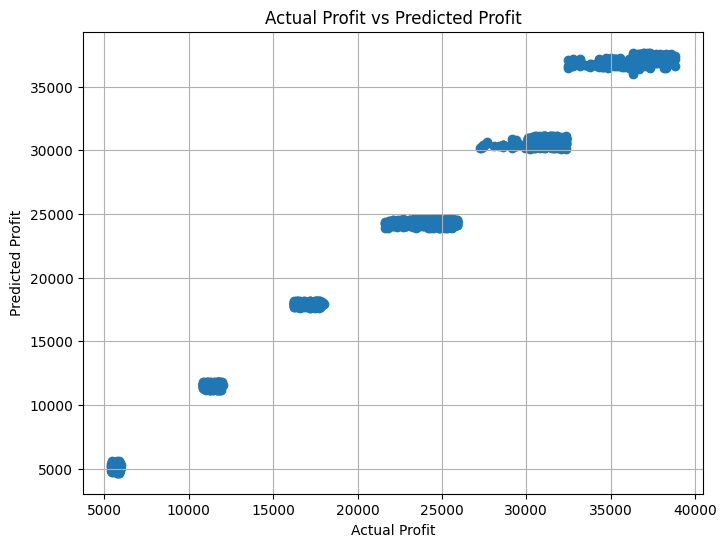

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    prediction
)

plt.xlabel("Actual Profit")

plt.ylabel("Predicted Profit")

plt.title("Actual Profit vs Predicted Profit")

plt.grid(True)

plt.show()


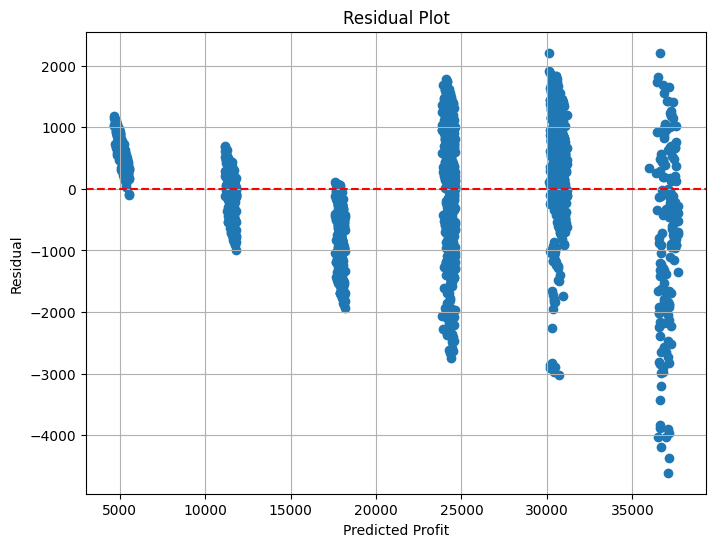

In [23]:
residual = y_test - prediction

plt.figure(figsize=(8,6))

plt.scatter(
    prediction,
    residual
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Profit")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

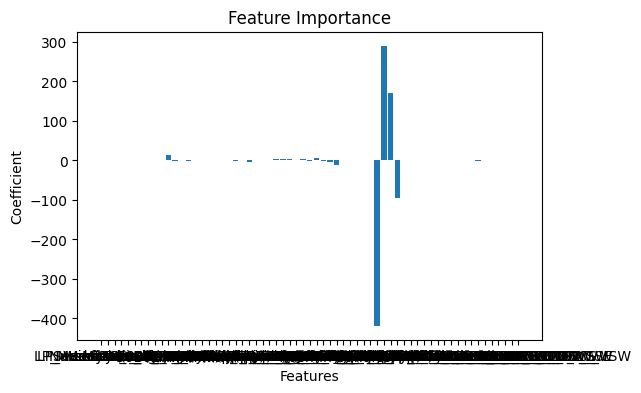

In [24]:
plt.figure(figsize=(6,4))

plt.bar(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Coefficient")

plt.show()